# Homework 1

In this assignment, we will be exploring the car dataset and analyzing their fuel efficiency. <br >
Specifically, we will do some exploratory analysis with visualizations, then we will build a model for Simple Linear Regression, a model for Polynomial Regression, and one model for Logistic Regression. <br >
**The given dataset is already modified and cleaned**, but you can find [the original information here.](https://archive.ics.uci.edu/ml/datasets/auto+mpg).

## Dataset Attribute Information

1. **mpg**: Miles per gallon. This is one primary measurement for car fuel efficiency.
2. **displacement** : The cylinder volumes in cubic inches.
3. **horsepower** : Engine power.
4. **weight** : In pounds.
5. **acceleration** : The elapsed time in seconds to go from 0 to 60mph.
6. **origin** : Region of origin.

### Libraries that can be used: numpy, pandas, scikit-learn, seaborn, plotly, matplotlib
Any libraries used in the discussion materials are also allowed.

#### Other Notes
 - Don't worry about not being able to achieve high accuracy, it is neither the goal nor the grading standard of **this** assignment. <br >
 - If not specified, you are not required to do hyperparameter tuning, but feel free to do so if you'd like.
 - Discussion materials should be helpful for doing the assignments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.svm import OneClassSVM

# Exercises
## Exercise 1 - Exploratory Analysis (20 points in total)

### Exercise 1.1 - Correlation Matrix (10 points)
Generate a Pearson [correlation matrix plot](https://heartbeat.fritz.ai/seaborn-heatmaps-13-ways-to-customize-correlation-matrix-visualizations-f1c49c816f07) in the form of a heatmap. See the link to have an idea about what this visualization should look like. <br >
After generating the plot, answer the following question: <br >
**If we are going to predict ``mpg`` in Simple Linear Regression(i.e., $y=ax+b$), which attribute are you most UNLIKELY to pick as the independent variable? Explain why.**

Requirements & notes
 - When computing correlation, make sure to drop the column ``origin`` to avoid errors.
 - The computed correlation values should be shown on the plot.
 - Use a diverging color scale with the color range being \[-1, 1\] and center being 0 (if applicable).

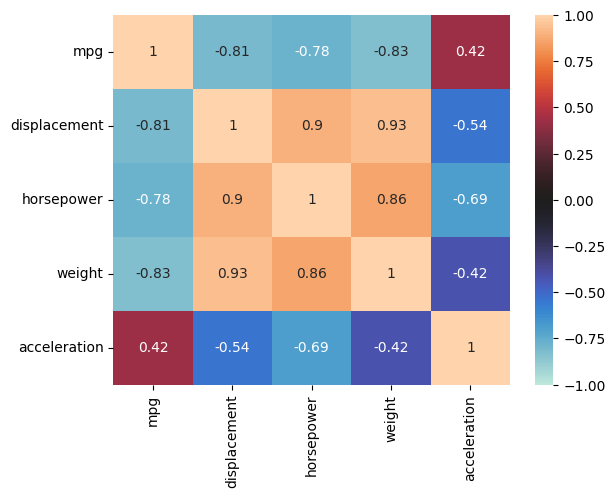

In [2]:
# correlation matrix
def gen_pearson(filename):
  '''
  make a correlation matrix plot in the form of a heatmap
  '''
  df = pd.read_csv(filename)

  # drop origin
  df = df.drop('origin', axis=1)
  sns.heatmap(df.corr(), annot=True, vmin=-1, vmax=1, center=0)

gen_pearson(filename='./auto-mpg.csv')
# We are most unlikely to pick acceleration as the independent variable because it has the lowest correlation out of all variables to mpg.

### Exercise 1.2 - Pairplot (10 points)
Generate a pairplot(a.k.a. scatter plot matrix) of the given dataset. <br >
After generating the plot, answer the following question: <br >
**If we are using ``horsepower`` to predict ``mpg``, which method could lead to the best performance? (Linear Regression, Polynomial Regression, or Logistic Regression) Explain why.**

Note that there is no requirement on the diagonals. You can leave empty or use other representations based on your preference. However, having ``origin``-based grouped data distributions on the diagonals effectively helps you answer some questions in the later exercises.   

Requirements
 - The points should be colored based on the column ``origin``.

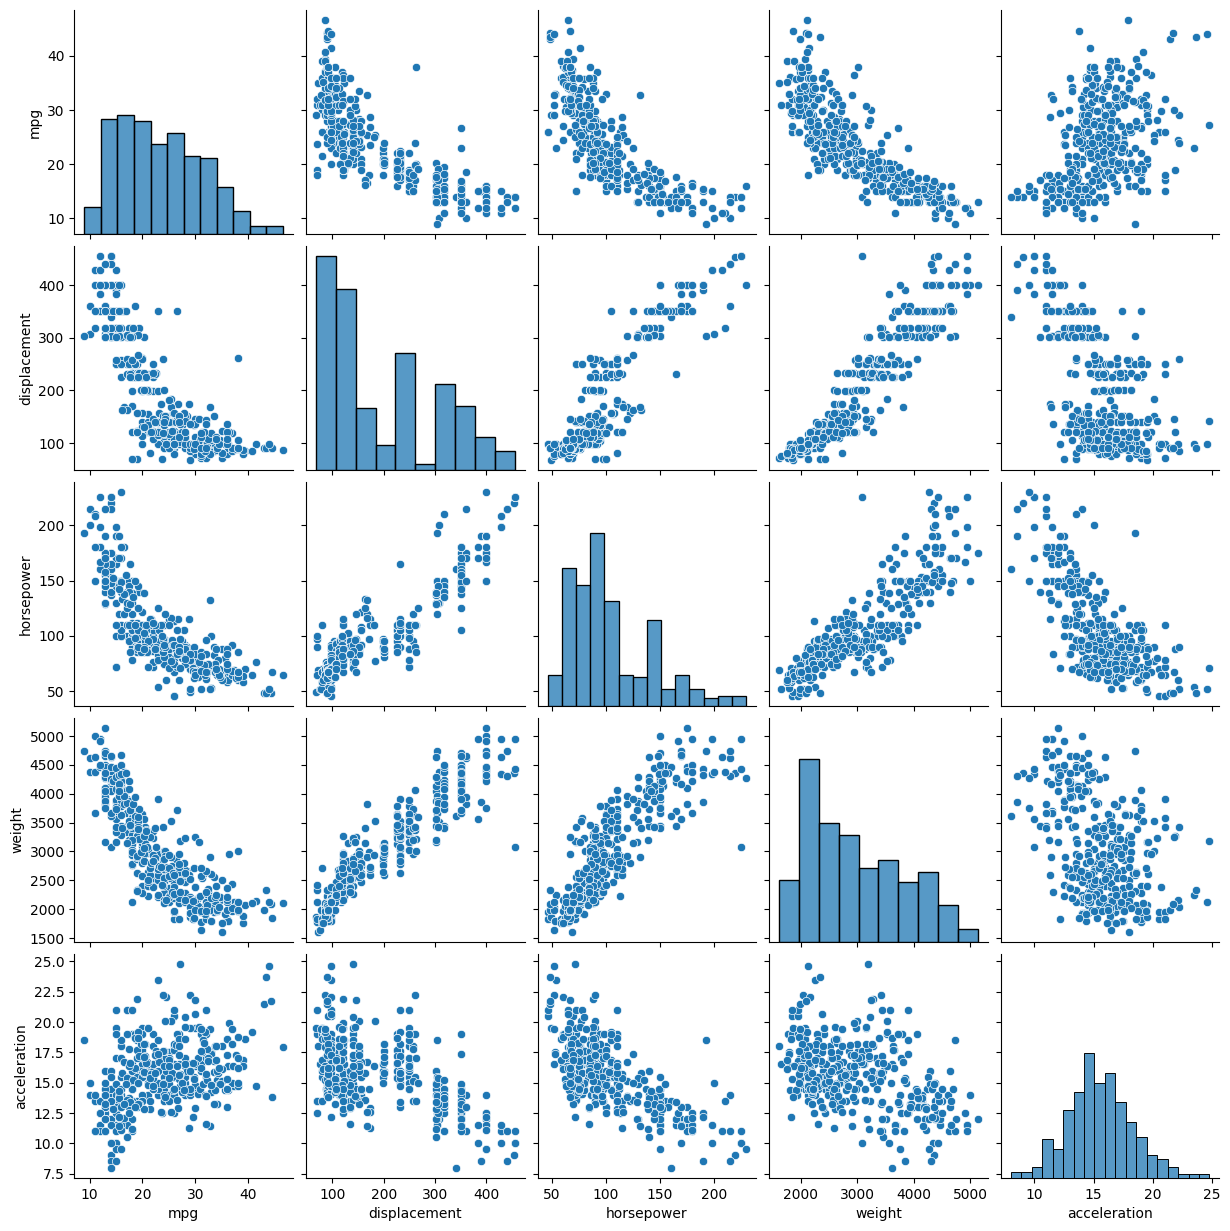

In [3]:
# generate a scatter plot matrix of the given dataset
def gen_pairplot(filename):
  df = pd.read_csv(filename)
  sns.pairplot(df)

gen_pairplot(filename='./auto-mpg.csv')
# Polynomial regression would be the best. Looking at row 1 column 3 the data follows a curved path
# this is best fit for a polynomial regression task, as a straight line would not accurately
# catch the full distribution of the data

## Exercise 2 - Linear and Polynomial Regression (30 points in total)

### Exercise 2.1 - Splitting Dataset (5 points)
Split the data into training and testing set with the ratio of 80:20.

In [4]:
df = pd.read_csv('./auto-mpg.csv')
df = df.drop('origin', axis=1)
X = df.drop('mpg', axis=1)
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Exercise 2.2 - Simple Linear Regression (10 points)
Using one of the other attributes(excluding ``origin``) by your choice, please build a simple linear regression model that predicts ``mpg``. <br >

Requirements
 - Report the testing MSE error.

In [5]:
def linear_reg():
  # use only one other attribute, not origin
  model = LinearRegression()
  train_features = (X_train[['weight']])
  train_labels = y_train

  test_features = (X_test[['weight']])
  test_labels = y_test

  model.fit(train_features,train_labels)
  score = model.score(test_features, test_labels)
  print('Model score is: ', score)

linear_reg()

Model score is:  0.6533466675646016


### Exercise 2.3 - Polynomial Regression (15 points)
Build polynomial regression models that predict ``mpg`` with the same choice in 2.2. <br >
Specifically, from degree=2 to degree=4, build one respectively. <br >
Then, based on the reported errors from only these three degrees, **do you think there is a sign of overfitting? Provide your reasoning.**


Requirements
 - Report the training MSE error for each of the three degrees.
 - Report the testing MSE error for each of the three degrees.


In [6]:
def poly_reg():
  model = sklearn.linear_model.LinearRegression()
  train_features = (X_train[['weight']])
  train_labels = y_train

  test_features = (X_test[['weight']])
  test_labels = y_test

  for i in range(2,5):
    # transform data
    poly = PolynomialFeatures(degree=i)
    X_poly = poly.fit_transform(train_features)
    X_poly_test = poly.transform(test_features)
    # train
    model = LinearRegression()
    model.fit(X_poly, train_labels)
    # get error
    mse_train = mean_squared_error(train_labels, model.predict(X_poly))
    y_pred = model.predict(X_poly_test)
    mse_test = mean_squared_error(y_test, y_pred)
    # report
    print(f"mse train for {i} degrees: {mse_train}")
    print(f"mse test for {i} degrees: {mse_test}")


poly_reg()
# I don't think there are signs of overfitting. Overfitting would mean that the MSE for training goes down as degree
# increases while the MSE for testing goes up. In all these cases the MSE of both seems fairly stable
# across the 3 degrees.

mse train for 2 degrees: 17.582965813534294
mse test for 2 degrees: 16.689074196036138
mse train for 3 degrees: 17.58294396630438
mse test for 3 degrees: 16.68945070366442
mse train for 4 degrees: 17.55321134626619
mse test for 4 degrees: 16.741184224792423


## Exercise 3 - Overfitting and Underfitting (25 points in total)
**The fitting dataset** contains the actual train and test data spread for a model along with three rotations of the same. The dataset is provided in the Canvas file.


### Exercise 3.1 - SSE
Calculate the SSE for the three predictions based on the actual data for train and test provided in the **Fitting CSV**.<br >
Show the calculation for the above metrics.<br >
Highlight the values you get for all three predictions and the actual data.


In [7]:
def sse():
  '''
  get sse for each of the predicitons
  '''
  df = pd.read_csv('./fitting.csv')
  # establish truth
  train_truth = np.array(df['Training Data'])
  test_truth = np.array(df['Test Data'])
  test_truth = test_truth[~np.isnan(test_truth)]

  train_cols = ['Prediction 1 Training', 'Prediction 2 Training',
       'Prediction 3 Training']
  test_cols = ['Prediction 1 Test', 'Prediction 2 Test', 'Prediction 3 Test']

  # go through each column
  for column in train_cols:
    prediction = np.array(df[column])
    # observed - predicted
    errors = train_truth - prediction
    squared_errors = errors ** 2
    sse = np.sum(squared_errors)
    print(f"SSE for {column}: {sse}")


  for column in test_cols:
    prediction = np.array(df[column])
    prediction = prediction[~np.isnan(prediction)]
    # observed - predicted
    errors = test_truth - prediction
    squared_errors = errors ** 2
    sse = np.sum(squared_errors)
    print(f"SSE for {column}: {sse}")


sse()

SSE for Prediction 1 Training: 12.2935
SSE for Prediction 2 Training: 12.336300000000003
SSE for Prediction 3 Training: 19.1735
SSE for Prediction 1 Test: 6.3418
SSE for Prediction 2 Test: 2.1254
SSE for Prediction 3 Test: 13.425899999999999


### Excercise 3.2 - Justification
Based on the values calculated above classify the predictions into three categories base prediction, overfitting prediction, underfitting prediction. Also provide appropriate justifications for the classifications.

Prediction 3 is underfitting prediciotn. This can be seen as both the training and test sse are poor.

Prediction 2 reflects overfitting. The training sse is strong, essentially the same as prediction 1, but its test prediction is much higher. Low error on training but hihg error on testing is what you typically see when a model overfits to the training data.

Prediction 3is base prediction. It performs well on both testing and training prediciton tasks.



## Exercise 4 - Outliers (25 points in total)
Now we are going to perform outlier detection using the diabetes dataset.
The dataset is provided in the Canvas file.

### Exercise 4.1 - box plot
Extract the 'BloodPressure' attribute from the diabetes dataset.<br >
Create a box plot with the 'BloodPressure' attribute.<br >
Highlight the outliers in the box plot with special colors.

In [8]:
df = pd.read_csv('diabetes.csv')

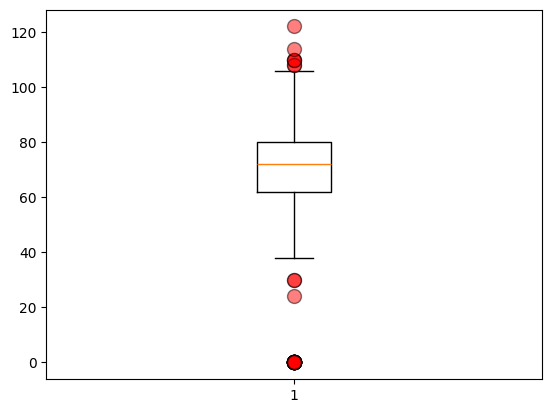

In [9]:
bp_data = np.array(df['BloodPressure'])
flier_style = dict(marker='o', markerfacecolor='red', markersize=10,
                   markeredgecolor='black', alpha=0.5)
plt.boxplot(bp_data, flierprops=flier_style)
plt.show()

### Exercise 4.2 - anomaly detection
Extract features 'BMI' and 'Insulin' from the diabetes dataset.<br >
Implement anomaly detection using the One-Class SVM algorithm.<br >
Plot a scatter plot similar to Lecture 2 Slide 11, annotating the outlier data points.

In [10]:
relevant_features = ['BMI', 'Insulin']
X = df[relevant_features].copy()
X_array = X.to_numpy()

# Instantiate the model
svm = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.03)
print("Model:", svm)

# Fit the model on ALL the data
# (One-Class SVM is unsupervised — there is no separate train/test split required,
#  though in practice you might hold out a validation set to tune hyperparameters)
svm.fit(X_array)

# Predict: +1 = inlier, -1 = outlier
predictions = svm.predict(X_array)

n_outliers = (predictions == -1).sum()
n_inliers  = (predictions == +1).sum()
print(f"\nTotal points : {len(predictions)}")
print(f"Inliers  (+1): {n_inliers}  ({100 * n_inliers / len(predictions):.1f}%)")
print(f"Outliers (-1): {n_outliers} ({100 * n_outliers / len(predictions):.1f}%)")


Model: OneClassSVM(gamma=0.001, nu=0.03)

Total points : 768
Inliers  (+1): 733  (95.4%)
Outliers (-1): 35 (4.6%)


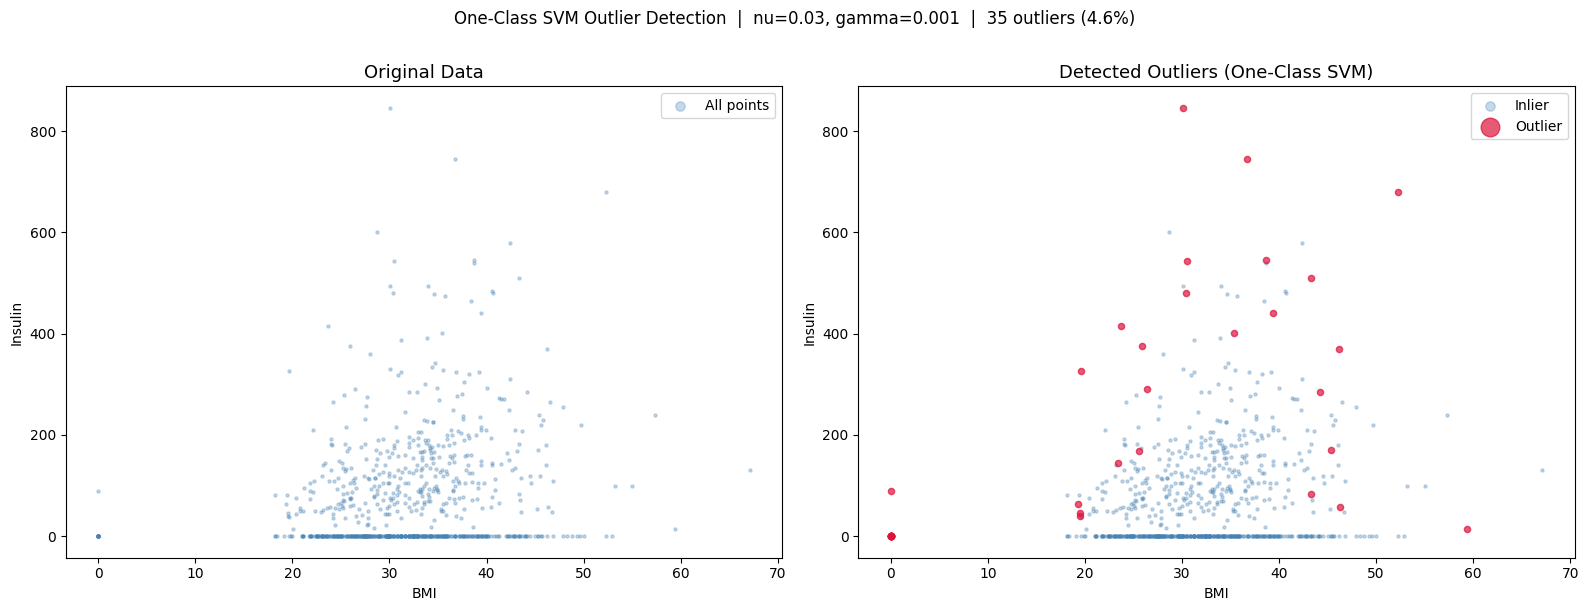

In [11]:
# Separate inliers and outliers for plotting
inlier_mask  = predictions == +1
outlier_mask = predictions == -1

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: all data (ground truth / original distribution) ---
ax0.scatter(
    X_array[:, 0], X_array[:, 1],
    s=5, alpha=0.3, color="steelblue", label="All points"
)
ax0.set_title("Original Data", fontsize=13)
ax0.set_xlabel("BMI")
ax0.set_ylabel("Insulin")
ax0.legend(markerscale=3)

# --- Right: inliers vs. outliers ---
ax1.scatter(
    X_array[inlier_mask, 0], X_array[inlier_mask, 1],
    s=5, alpha=0.3, color="steelblue", label="Inlier"
)
ax1.scatter(
    X_array[outlier_mask, 0], X_array[outlier_mask, 1],
    s=20, alpha=0.7, color="crimson", label="Outlier"
)
ax1.set_title("Detected Outliers (One-Class SVM)", fontsize=13)
ax1.set_xlabel("BMI")
ax1.set_ylabel("Insulin")
ax1.legend(markerscale=3)

plt.suptitle(
    f"One-Class SVM Outlier Detection  |  nu={svm.nu}, gamma={svm.gamma}  |  "
    f"{n_outliers} outliers ({100 * n_outliers / len(predictions):.1f}%)",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()